In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import percentileofscore

import warnings
warnings.filterwarnings("ignore")

In [3]:
import os

base_path = "../data/processed"

fund_master = pd.read_csv(
    f"{base_path}/fund_master.csv"
)

nav = pd.read_csv(
    f"{base_path}/nav_history.csv"
)

performance = pd.read_csv(
    f"{base_path}/scheme_performance.csv"
)

transactions = pd.read_csv(
    f"{base_path}/investor_transactions.csv"
)

holdings = pd.read_csv(
    f"{base_path}/portfolio_holdings.csv"
)

benchmark = pd.read_csv(
    f"{base_path}/benchmark_indices.csv"
)

print("Fund Master:", fund_master.shape)
print("NAV:", nav.shape)
print("Performance:", performance.shape)
print("Transactions:", transactions.shape)
print("Holdings:", holdings.shape)
print("Benchmark:", benchmark.shape)

Fund Master: (40, 15)
NAV: (46000, 3)
Performance: (40, 19)
Transactions: (32778, 13)
Holdings: (322, 8)
Benchmark: (8050, 3)


In [4]:
nav["date"] = pd.to_datetime(nav["date"])

nav["nav"] = pd.to_numeric(
    nav["nav"],
    errors="coerce"
)

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

print(nav.head())

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210


In [5]:
print(
    nav["amfi_code"].nunique()
)

40


In [7]:
var_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) == 0:
        continue

    var_95 = returns.quantile(0.05)

    cvar_95 = returns[
        returns <= var_95
    ].mean()

    var_results.append({
        "amfi_code": amfi_code,
        "VaR_95": var_95,
        "CVaR_95": cvar_95,
        "observations": len(returns)
    })

var_cvar = pd.DataFrame(var_results)

print(var_cvar.head())
print(var_cvar.shape)

   amfi_code    VaR_95   CVaR_95  observations
0     100016 -0.014364 -0.018060          1149
1     100025 -0.003793 -0.004994          1149
2     100033 -0.019034 -0.023456          1149
3     101206 -0.013282 -0.017439          1149
4     101207 -0.026021 -0.032459          1149
(40, 4)


In [8]:
var_cvar = var_cvar.merge(
    fund_master[
        ["amfi_code", "scheme_name", "fund_house"]
    ],
    on="amfi_code",
    how="left"
)

In [9]:
var_cvar = var_cvar[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "VaR_95",
        "CVaR_95",
        "observations"
    ]
]

In [10]:
os.makedirs("../reports", exist_ok=True)

var_cvar.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("VaR/CVaR report saved.")

VaR/CVaR report saved.


In [15]:
nav = pd.read_csv("../data/processed/nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

print(nav.head(10))
key_funds = [
    125497,  # HDFC Top 100
    119551,  # SBI Bluechip
    120503,  # ICICI Bluechip
    118632,  # Nippon Large Cap
    119092   # Axis Bluechip
]

print(key_funds)

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639
6     100016 2022-01-11  513.5542      0.005562
7     100016 2022-01-12  512.3195     -0.002404
8     100016 2022-01-13  510.2445     -0.004050
9     100016 2022-01-14  514.3636      0.008073
[125497, 119551, 120503, 118632, 119092]


In [16]:
rolling_data = nav[
    nav["amfi_code"].isin(key_funds)
].copy()

rolling_data["rolling_sharpe_90"] = (
    rolling_data
    .groupby("amfi_code")["daily_return"]
    .transform(
        lambda x:
        x.rolling(90).mean()
        /
        x.rolling(90).std()
        * np.sqrt(252)
    )
)

In [17]:
rolling_data = rolling_data.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

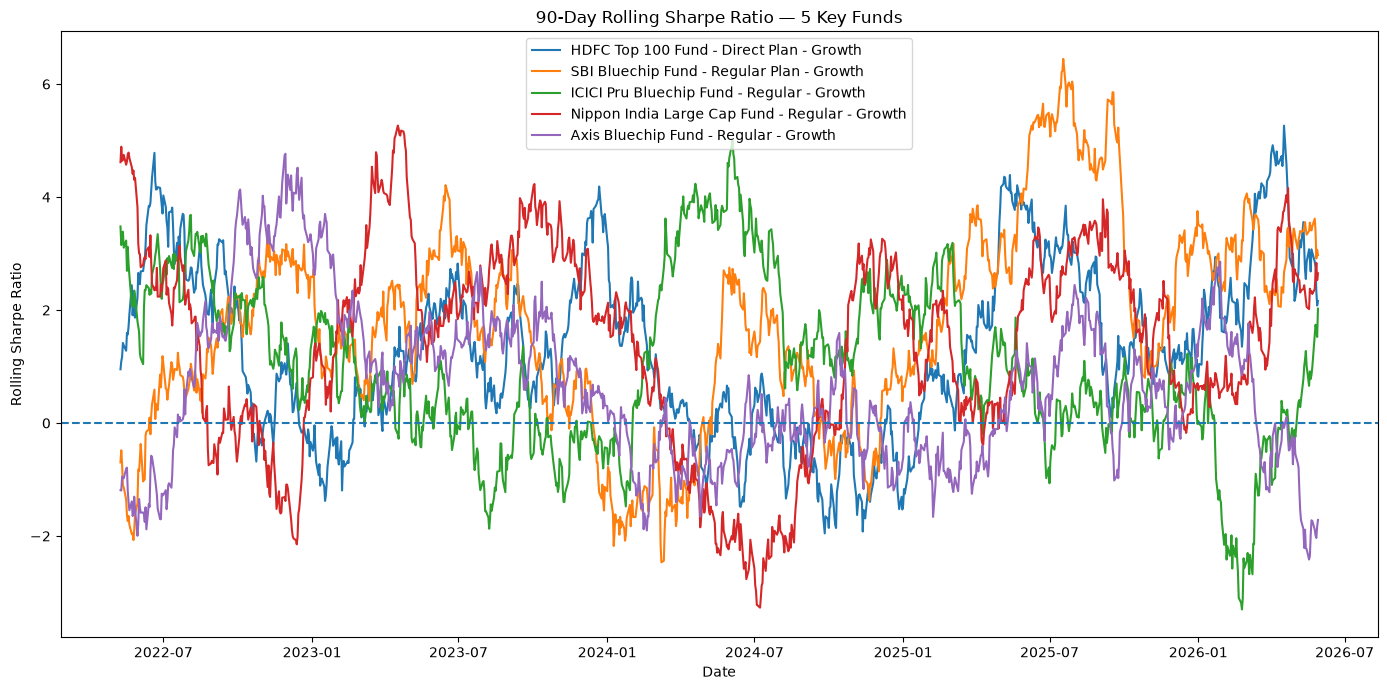

In [18]:
plt.figure(figsize=(14, 7))

for fund in key_funds:

    temp = rolling_data[
        rolling_data["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe_90"],
        label=temp["scheme_name"].iloc[0]
    )

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "90-Day Rolling Sharpe Ratio — 5 Key Funds"
)

plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")

plt.legend()
plt.tight_layout()

plt.savefig(
    "../rolling_sharpe_chart.png",
    dpi=300
)

plt.show()

In [19]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

transactions["amount_inr"] = pd.to_numeric(
    transactions["amount_inr"],
    errors="coerce"
)

In [20]:
first_transaction = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_transaction["cohort_year"] = (
    first_transaction["transaction_date"]
    .dt.year
)

transactions = transactions.merge(
    first_transaction[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id",
    how="left"
)

In [21]:
cohort_summary = (
    transactions
    .groupby("cohort_year")
    .agg(
        avg_transaction_amount=(
            "amount_inr",
            "mean"
        ),
        total_invested=(
            "amount_inr",
            "sum"
        ),
        investors=(
            "investor_id",
            "nunique"
        )
    )
    .reset_index()
)

print(cohort_summary)

   cohort_year  avg_transaction_amount  total_invested  investors
0         2024           107422.541832      3491125187       4803
1         2025           109158.577061        30455243        197


In [22]:
fund_preference = (
    transactions
    .groupby(
        ["cohort_year", "amfi_code"]
    )
    .size()
    .reset_index(name="transactions")
)

top_funds = (
    fund_preference
    .sort_values(
        ["cohort_year", "transactions"],
        ascending=[True, False]
    )
    .groupby("cohort_year")
    .head(1)
)

top_funds = top_funds.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

print(top_funds)

   cohort_year  amfi_code  transactions  \
0         2024     148568           874   
1         2025     119599            12   

                                         scheme_name  
0  Mirae Asset Emerging Bluechip Fund - Regular -...  
1          SBI Small Cap Fund - Direct Plan - Growth  


In [23]:
sip = transactions[
    transactions["transaction_type"]
    .str.strip()
    .str.upper()
    == "SIP"
].copy()

print(
    sip["investor_id"].nunique()
)

4762


In [24]:
sip = sip.sort_values(
    ["investor_id", "transaction_date"]
)

sip["gap_days"] = (
    sip.groupby("investor_id")["transaction_date"]
       .diff()
       .dt.days
)

In [25]:
sip_counts = (
    sip.groupby("investor_id")
       .size()
       .reset_index(name="sip_count")
)

eligible = sip_counts[
    sip_counts["sip_count"] >= 6
]

print(
    "Eligible investors:",
    len(eligible)
)

Eligible investors: 1362


In [27]:
continuity_summary = (
    continuity
    .groupby("investor_id")
    .agg(
        sip_count=("transaction_date", "count"),
        avg_gap_days=("gap_days", "mean")
    )
    .reset_index()
)

print(continuity_summary.head())

  investor_id  sip_count  avg_gap_days
0   INV000004          6     85.400000
1   INV000008          6     70.400000
2   INV000010          6     64.800000
3   INV000011          7     40.166667
4   INV000012          8     57.000000


In [29]:
continuity = sip.merge(
    eligible[["investor_id"]],
    on="investor_id",
    how="inner"
)

continuity_summary = (
    continuity
    .groupby("investor_id")
    .agg(
        
        sip_count=("transaction_date", "count"),
        avg_gap_days=("gap_days", "mean")
    )
    .reset_index()
)

In [30]:
continuity_summary["status"] = np.where(
    continuity_summary["avg_gap_days"] > 35,
    "At-Risk",
    "Regular"
)

In [31]:
print(
    continuity_summary["status"]
    .value_counts()
)

status
At-Risk    1332
Regular      30
Name: count, dtype: int64


In [32]:
holdings["weight_pct"] = pd.to_numeric(
    holdings["weight_pct"],
    errors="coerce"
)

holdings["weight"] = (
    holdings["weight_pct"] / 100
)

In [33]:
hhi = (
    holdings
    .groupby("amfi_code")
    .apply(
        lambda x:
        (x["weight"] ** 2).sum()
    )
    .reset_index(
        name="sector_hhi"
    )
)

In [34]:
hhi = hhi.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "category"
        ]
    ],
    on="amfi_code",
    how="left"
)

In [35]:
equity_hhi = hhi[
    hhi["category"]
    .astype(str)
    .str.contains(
        "equity",
        case=False,
        na=False
    )
]

In [36]:
equity_hhi = equity_hhi.sort_values(
    "sector_hhi",
    ascending=False
)

print(
    equity_hhi.head(10)
)

    amfi_code  sector_hhi                                        scheme_name  \
11     119092    0.206448              Axis Bluechip Fund - Regular - Growth   
3      101207    0.200700             ABSL Small Cap Fund - Regular - Growth   
18     119599    0.174751          SBI Small Cap Fund - Direct Plan - Growth   
4      102885    0.174709         UTI Nifty 50 Index Fund - Regular - Growth   
7      118632    0.168298     Nippon India Large Cap Fund - Regular - Growth   
29     148568    0.167930  Mirae Asset Emerging Bluechip Fund - Regular -...   
21     120505    0.157570           ICICI Pru Midcap Fund - Regular - Growth   
22     120506    0.153794  ICICI Pru Value Discovery Fund - Regular - Growth   
27     125498    0.152414  HDFC Mid-Cap Opportunities Fund - Direct - Growth   
23     120841    0.149680             Kotak Bluechip Fund - Regular - Growth   

   category  
11   Equity  
3    Equity  
18   Equity  
4    Equity  
7    Equity  
29   Equity  
21   Equity  
22   Eq

Insight 1 — Downside Risk

The funds with the most negative 95% VaR and CVaR experienced the largest historical daily downside losses, indicating higher short-term downside risk.

In [37]:
var_cvar.sort_values("VaR_95").head(5)

,amfi_code,scheme_name,fund_house,VaR_95,CVaR_95,observations
22,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,-0.026859,-0.032384,1149
17,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,-0.026188,-0.031667,1149
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,-0.026021,-0.032459,1149
11,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,-0.025438,-0.032304,1149
21,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,-0.024507,-0.030595,1149


Insight 2 — Investor Cohorts

The cohort analysis shows which investor entry years contributed the highest total invested amount and reveals differences in average transaction size across cohorts.

In [38]:
cohort_summary.sort_values(
    "total_invested",
    ascending=False
)

,cohort_year,avg_transaction_amount,total_invested,investors
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


Insight 3 — SIP Continuity

Investors with an average SIP gap above 35 days are classified as at-risk, providing an indicator of potential SIP discontinuity.

In [39]:
continuity_summary["status"].value_counts()

status
At-Risk    1332
Regular      30
Name: count, dtype: int64

Insight 4 — Sector Concentration

Funds with higher HHI values have more concentrated sector allocations, while lower HHI values indicate more diversified sector exposure.

Insight 5 — Risk-adjusted Performance

The fund recommender identifies the three funds with the highest Sharpe ratios within each risk grade, highlighting funds with stronger historical risk-adjusted performance.

In [41]:
print(var_cvar.shape)
print(var_cvar.head())

(40, 6)
   amfi_code                                        scheme_name  \
0     100016          HDFC Top 100 Fund - Regular Plan - Growth   
1     100025       HDFC Short Term Debt Fund - Regular - Growth   
2     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
3     101206      ABSL Frontline Equity Fund - Regular - Growth   
4     101207             ABSL Small Cap Fund - Regular - Growth   

                 fund_house    VaR_95   CVaR_95  observations  
0          HDFC Mutual Fund -0.014364 -0.018060          1149  
1          HDFC Mutual Fund -0.003793 -0.004994          1149  
2          HDFC Mutual Fund -0.019034 -0.023456          1149  
3  Aditya Birla Sun Life MF -0.013282 -0.017439          1149  
4  Aditya Birla Sun Life MF -0.026021 -0.032459          1149  
